# 1) Текстовое описание набора данных
В данной лабораторной работе используется набор данных "Screen Time, Sleep & Stress Analysis Dataset", доступный на платформе Kaggle по адресу: https://www.kaggle.com/datasets/amar5693/screen-time-sleep-and-stress-analysis-dataset.
Данный датасет создан для анализа взаимосвязей между использованием смартфона, режимом сна, продуктивностью и уровнем стресса у пользователей. 
Датасет содержит 50 000 записей о пользователях и включает следующие признаки:
Демографические данные:
•	User_ID: Уникальный идентификатор пользователя
•	Age: Возраст пользователя 
•	Gender: Пол
•	Occupation: Род занятий 
•	Device_Type: Тип устройства 
Показатели использования устройств:
•	Daily_Phone_Hours: Среднее ежедневное время использования телефона (в часах)
•	Social_Media_Hours: Ежедневное время, проведенное в социальных сетях (в часах)
•	App_Usage_Count: Количество используемых приложений в день
•	Weekend_Screen_Time_Hours: Время экрана в выходные дни (в часах)
Показатели образа жизни:
•	Caffeine_Intake_Cups: Ежедневное потребление кофеина (в чашках)
Целевые/поведенческие показатели:
•	Work_Productivity_Score: Оценка продуктивности работы (шкала от 1 до 10)
•	Sleep_Hours: Средняя продолжительность сна (в часах)
•	Stress_Level: Уровень стресса (шкала от 1 до 10)


# Импорт библиотек 

In [78]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#здесь же настроим стиль графиков
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
print("Библиотеки импортированы")

Библиотеки импортированы


# 2) Загрузка данных и изучение основных характеристик 


In [80]:
### data = pd.read_csv('/Users/User/Desktop/Uni/6 семестр/Технологии машнного обучения/Лабораторная работа 1/Smartphone_Usage_Productivity_Dataset_50000.csv')

print("\nПервые 5 строк:")
data.head()

#размер датасета(строки, колонки)
print("\nКоличество строк и колонок:", data.shape)


#поиск пропущенных значений
print("\nЗначений пропущено:", data.isnull().sum())

#проверим наличие пустых значений по колонкам
"""
for col in data.columns:
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))
"""
#список колонок
data.columns

#список колонок с типами данных
data.dtypes

print("\nОсновные статистические характеристики:", data.describe())

#уникальные значения в некоторых из категорий
print("Уникальные значения в категориях:")
print(f"Gender: {data['Gender'].unique()}")
print(f"Occupation: {data['Occupation'].unique()}")
print(f"Device_Type: {data['Device_Type'].unique()}")





Первые 5 строк:

Количество строк и колонок: (50000, 13)

Значений пропущено: User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

Основные статистические характеристики:                 Age  Daily_Phone_Hours  Social_Media_Hours  \
count  50000.000000       50000.000000        50000.000000   
mean      39.034960           6.509116            4.267250   
std       12.414877           3.170903            2.164743   
min       18.000000           1.000000            0.500000   
25%       28.000000           3.800000            2.400000   
50%       39.000000           6.500000            4.300000   
75%       50.000000           

# 3) Визуальное исследование датасета

## Гистограмма 

Позволяет оценить плотность вероятности распределения данных.


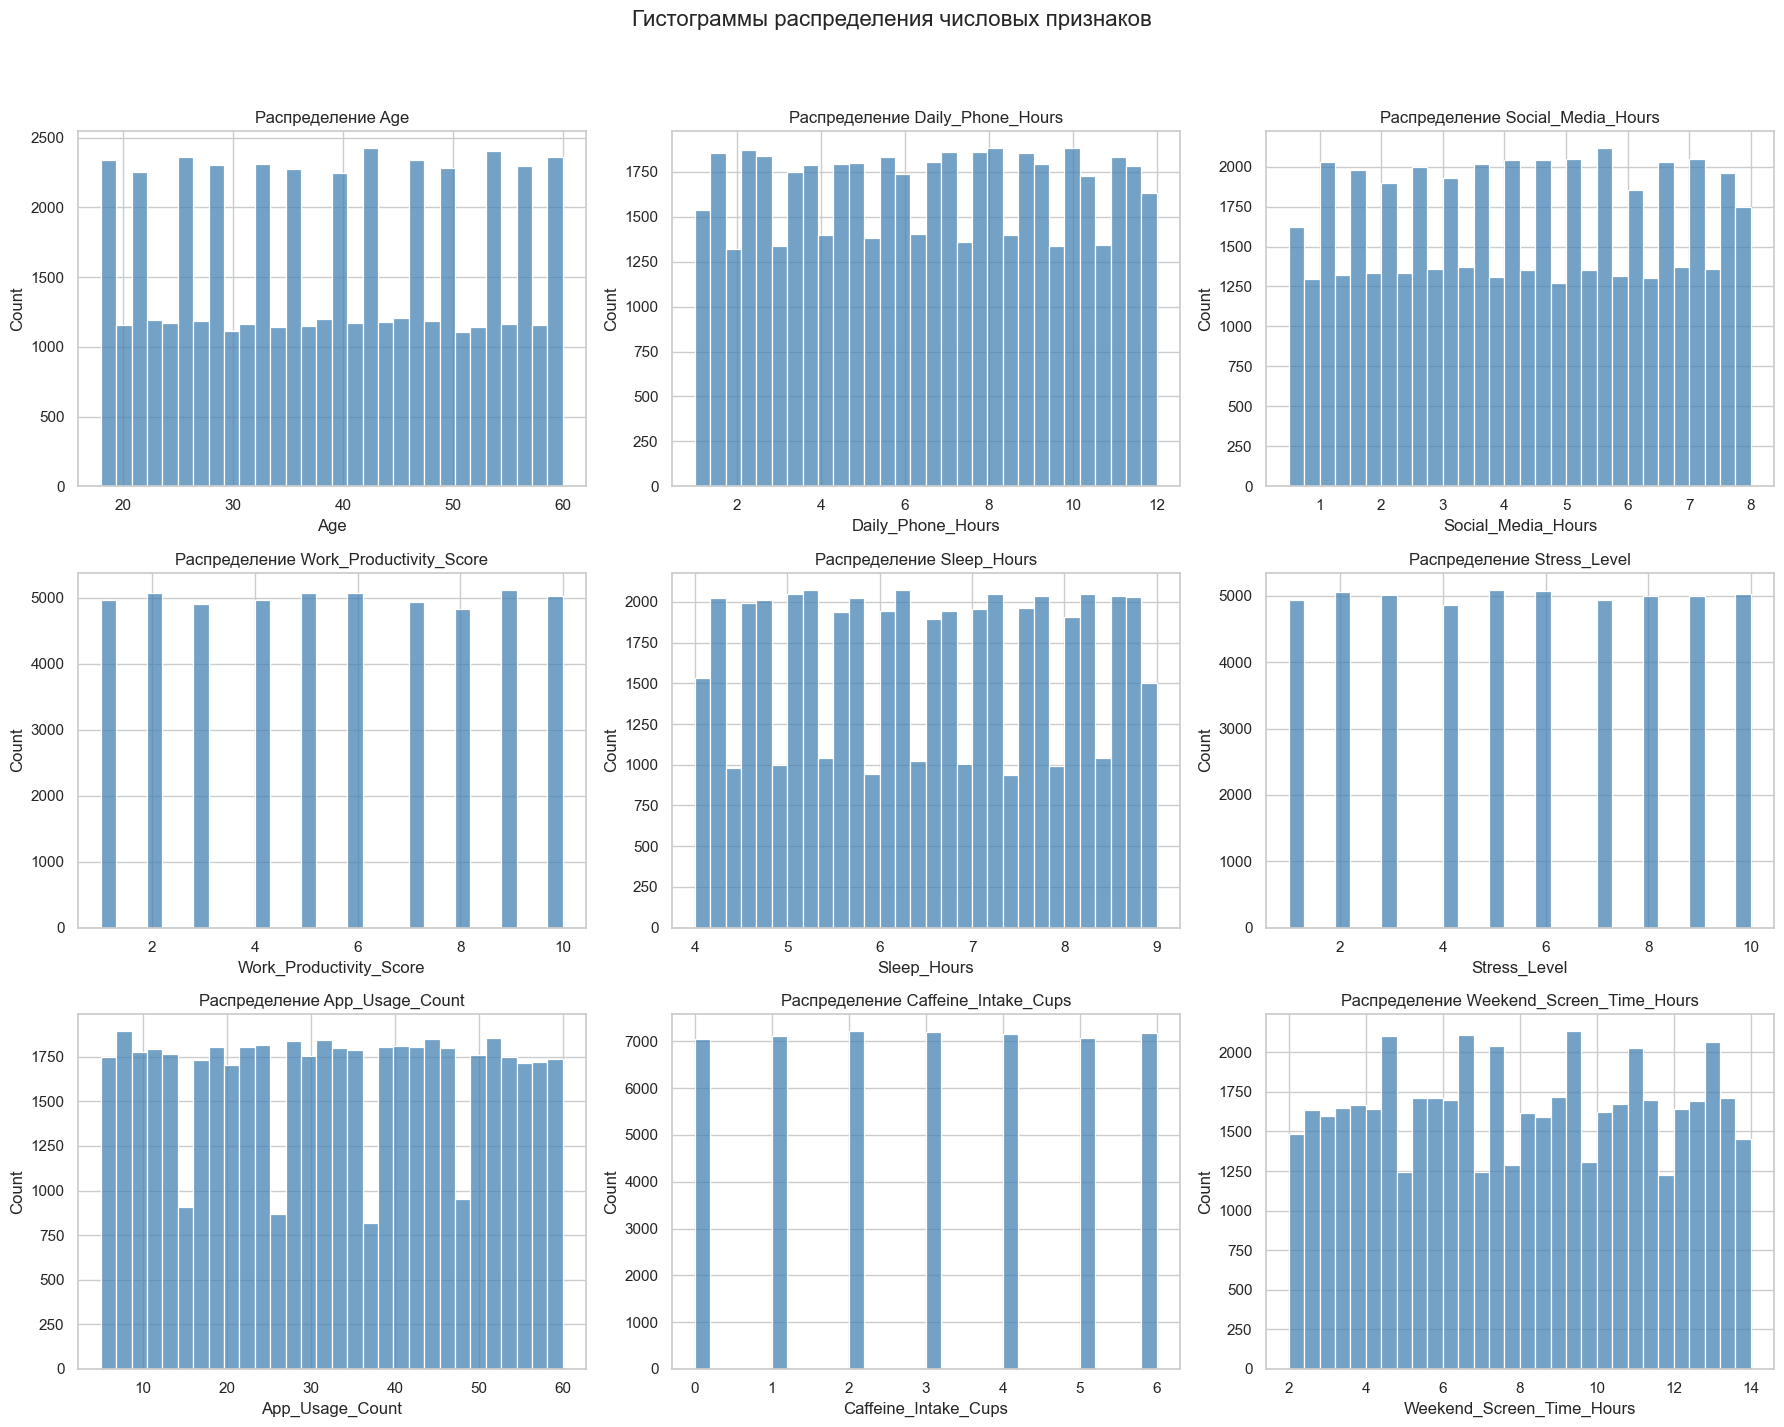

In [18]:
#создаем фигуру с сеткой подграфиков 3-3
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Гистограммы распределения числовых признаков', fontsize=16)

#признаки для визуализации
numeric_features= ['Age', 'Daily_Phone_Hours', 'Social_Media_Hours', 
                    'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level',
                    'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours']

#цикл для создания 9 графиков внутри сетки
for i, feature in enumerate(numeric_features):
    # Определяем позицию графика (3 строки, 3 столбца)
    row = i//3  #целочисленное деление для номера строки (0, 1, 2)
    col = i%3   #остаток от деления для номера столбца (в итоге 00, 01, 02, 10 и тд)
    
    #строим гистограмму
    sns.histplot(data[feature], kde=False, ax=axes[row, col], bins=30, color='steelblue')
    axes[row, col].set_title(f'Распределение {feature}')
    axes[row, col].set_xlabel(feature)

# расстояния между графиками
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Столбчатые диаграммы для категорий

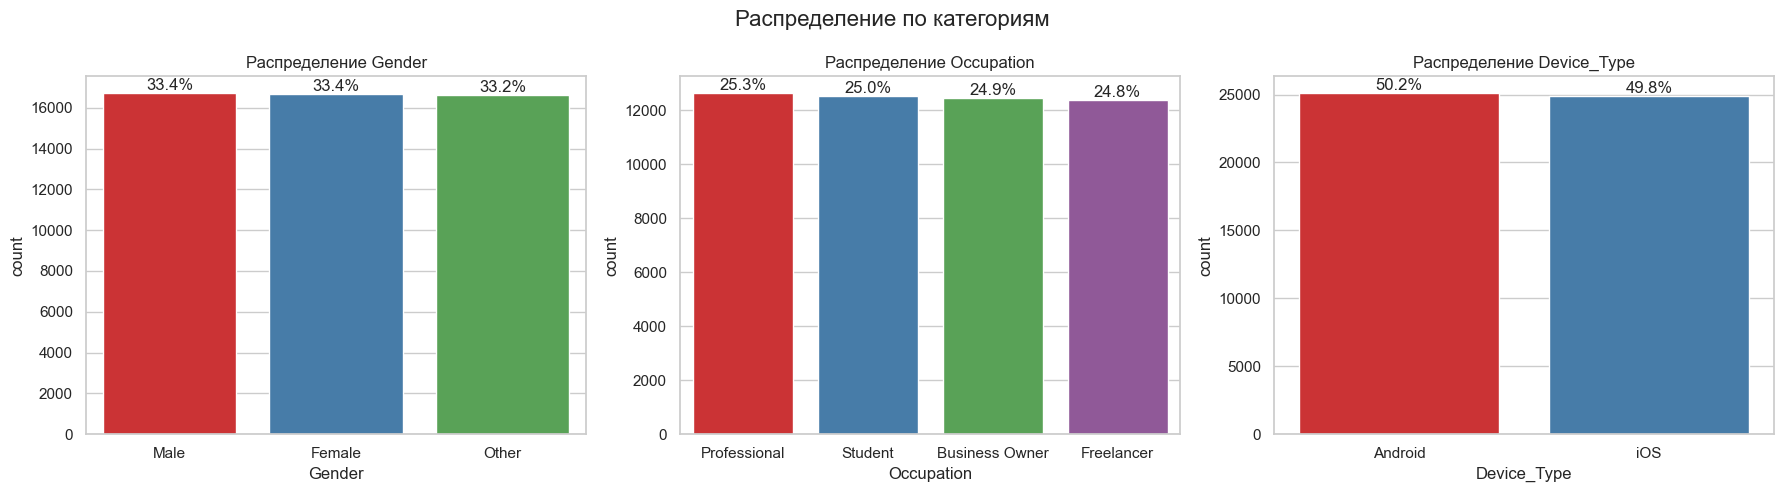

In [82]:
#создаем фигуру с тремя подграфиками в ряд
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Распределение по категориям', fontsize=16)

categorical_features = ['Gender', 'Occupation', 'Device_Type']

for i, feature in enumerate(categorical_features):
    #строим столбчатую диаграмму
    sns.countplot(data=data, x=feature, hue=feature, ax=axes[i], palette='Set1', legend=False)
    axes[i].set_title(f'Распределение {feature}')
    
    #добавляем проценты
    total = len(data)
    for p in axes[i].patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        axes[i].annotate(percentage, (p.get_x() + p.get_width()/2., p.get_height()), 
                        ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Диаграмма рассеяния

Позволяет построить распределение двух колонок данных и визуально обнаружить наличие зависимости. Не предполагается, что значения упорядочены (например, по времени).

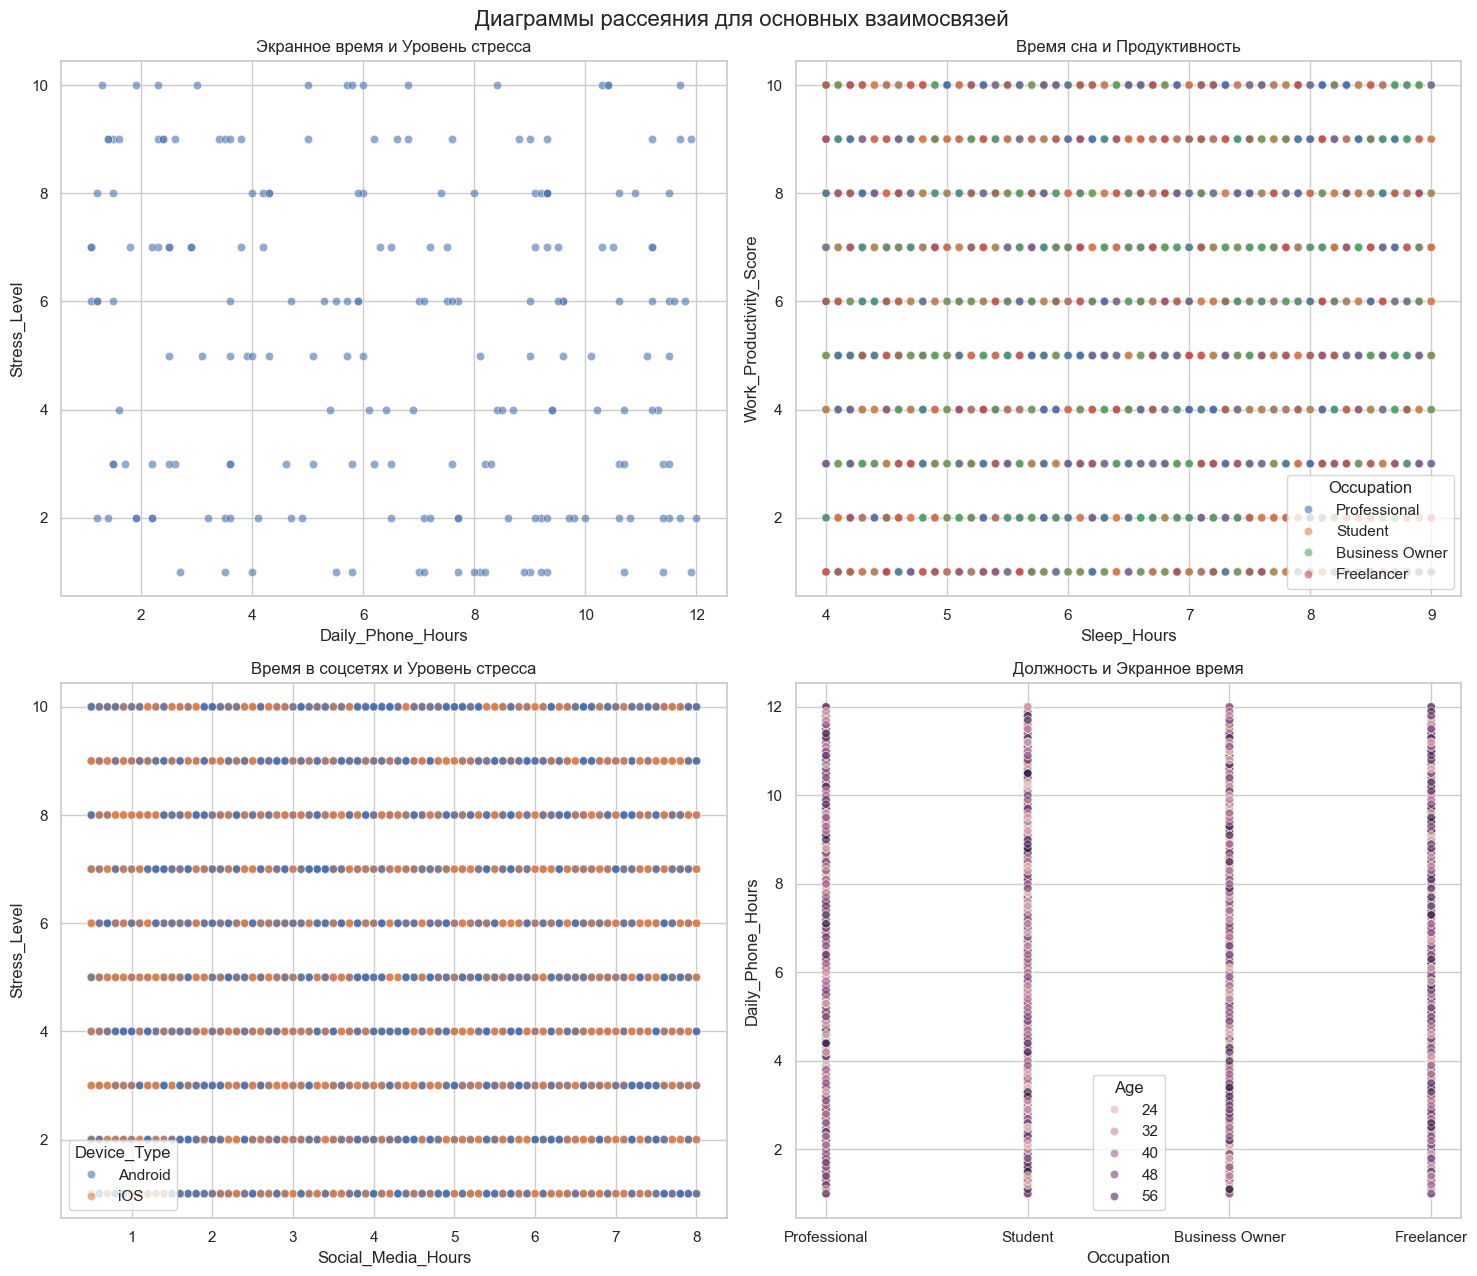

In [87]:
#сетка 2-2
fig, axes= plt.subplots(2, 2, figsize=(15, 13))
fig.suptitle('Диаграммы рассеяния для основных взаимосвязей', fontsize=16)

data_sample = data.sample(n=200, random_state=42)

#график 1-экранное время и уровень стресса
sns.scatterplot(data=data_sample, x='Daily_Phone_Hours', y='Stress_Level', alpha=0.6, ax=axes[0,0])
axes[0,0].set_title('Экранное время и Уровень стресса')

#график 2-время сна и продуктивность
sns.scatterplot(data=data, x='Sleep_Hours', y='Work_Productivity_Score', 
                hue='Occupation', alpha=0.6, ax=axes[0,1])
axes[0,1].set_title('Время сна и Продуктивность')

#график 3-время в соцсетях и  уровень стресса
sns.scatterplot(data=data, x='Social_Media_Hours', y='Stress_Level', 
                hue='Device_Type', alpha=0.6, ax=axes[1,0])
axes[1,0].set_title('Время в соцсетях и Уровень стресса')

sns.scatterplot(data=data, x='Occupation', y='Daily_Phone_Hours', 
                hue='Age', alpha=0.6, ax=axes[1,1])
axes[1,1].set_title('Должность и Экранное время')


plt.tight_layout()
plt.show()

## Pairplot (матрица диаграмм рассеяния)

Построим для ограниченной выборки (150) для большей наглядности:


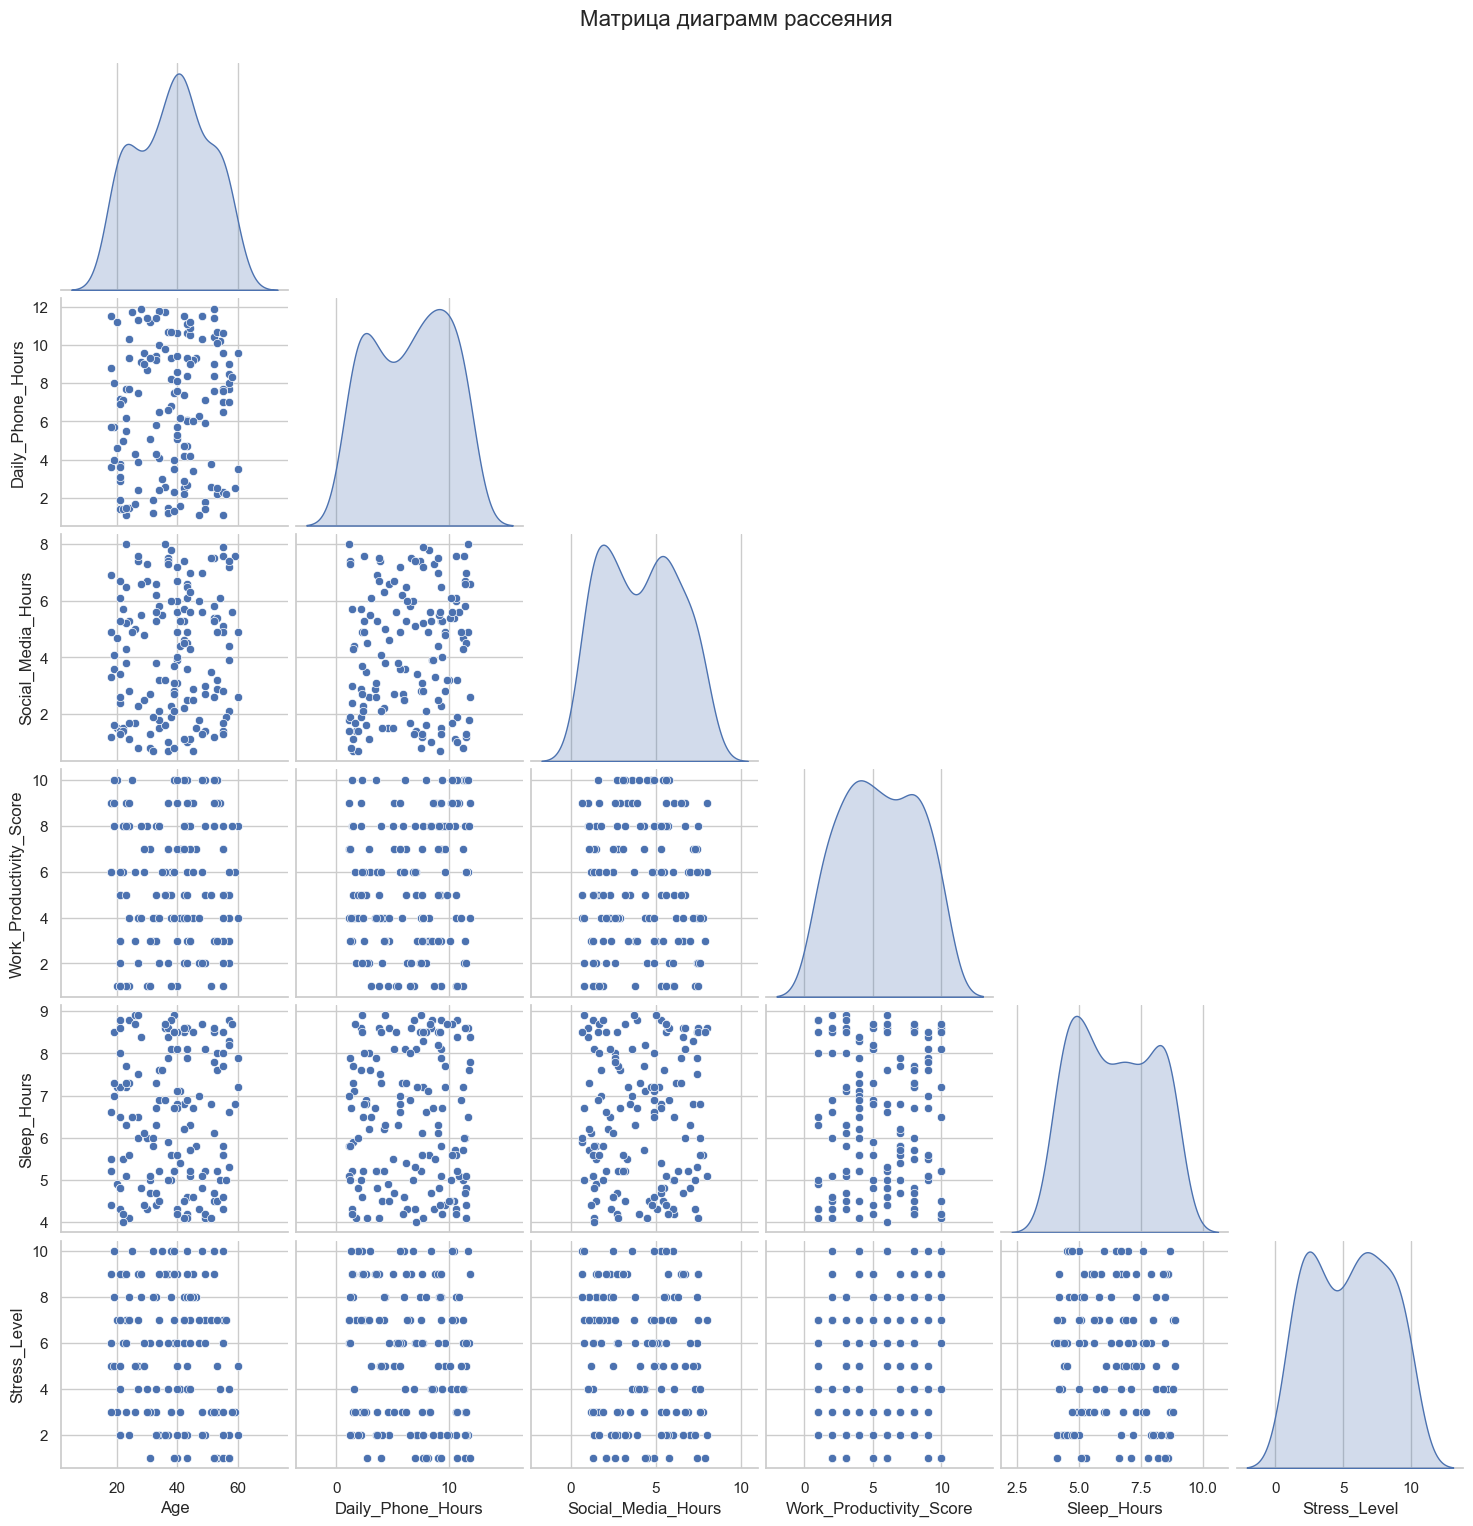

In [125]:
data_sample = data.sample(n=150, random_state=42)

#ключевые признаки
key_features = ['Age', 'Daily_Phone_Hours', 'Social_Media_Hours', 
                'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level']

#строим pairplot
sns.pairplot(data_sample[key_features], diag_kind='kde', corner=True)
plt.suptitle('Матрица диаграмм рассеяния', y=1.02, fontsize=16)
plt.show()

## Диаграмма размаха (ящик с усами)

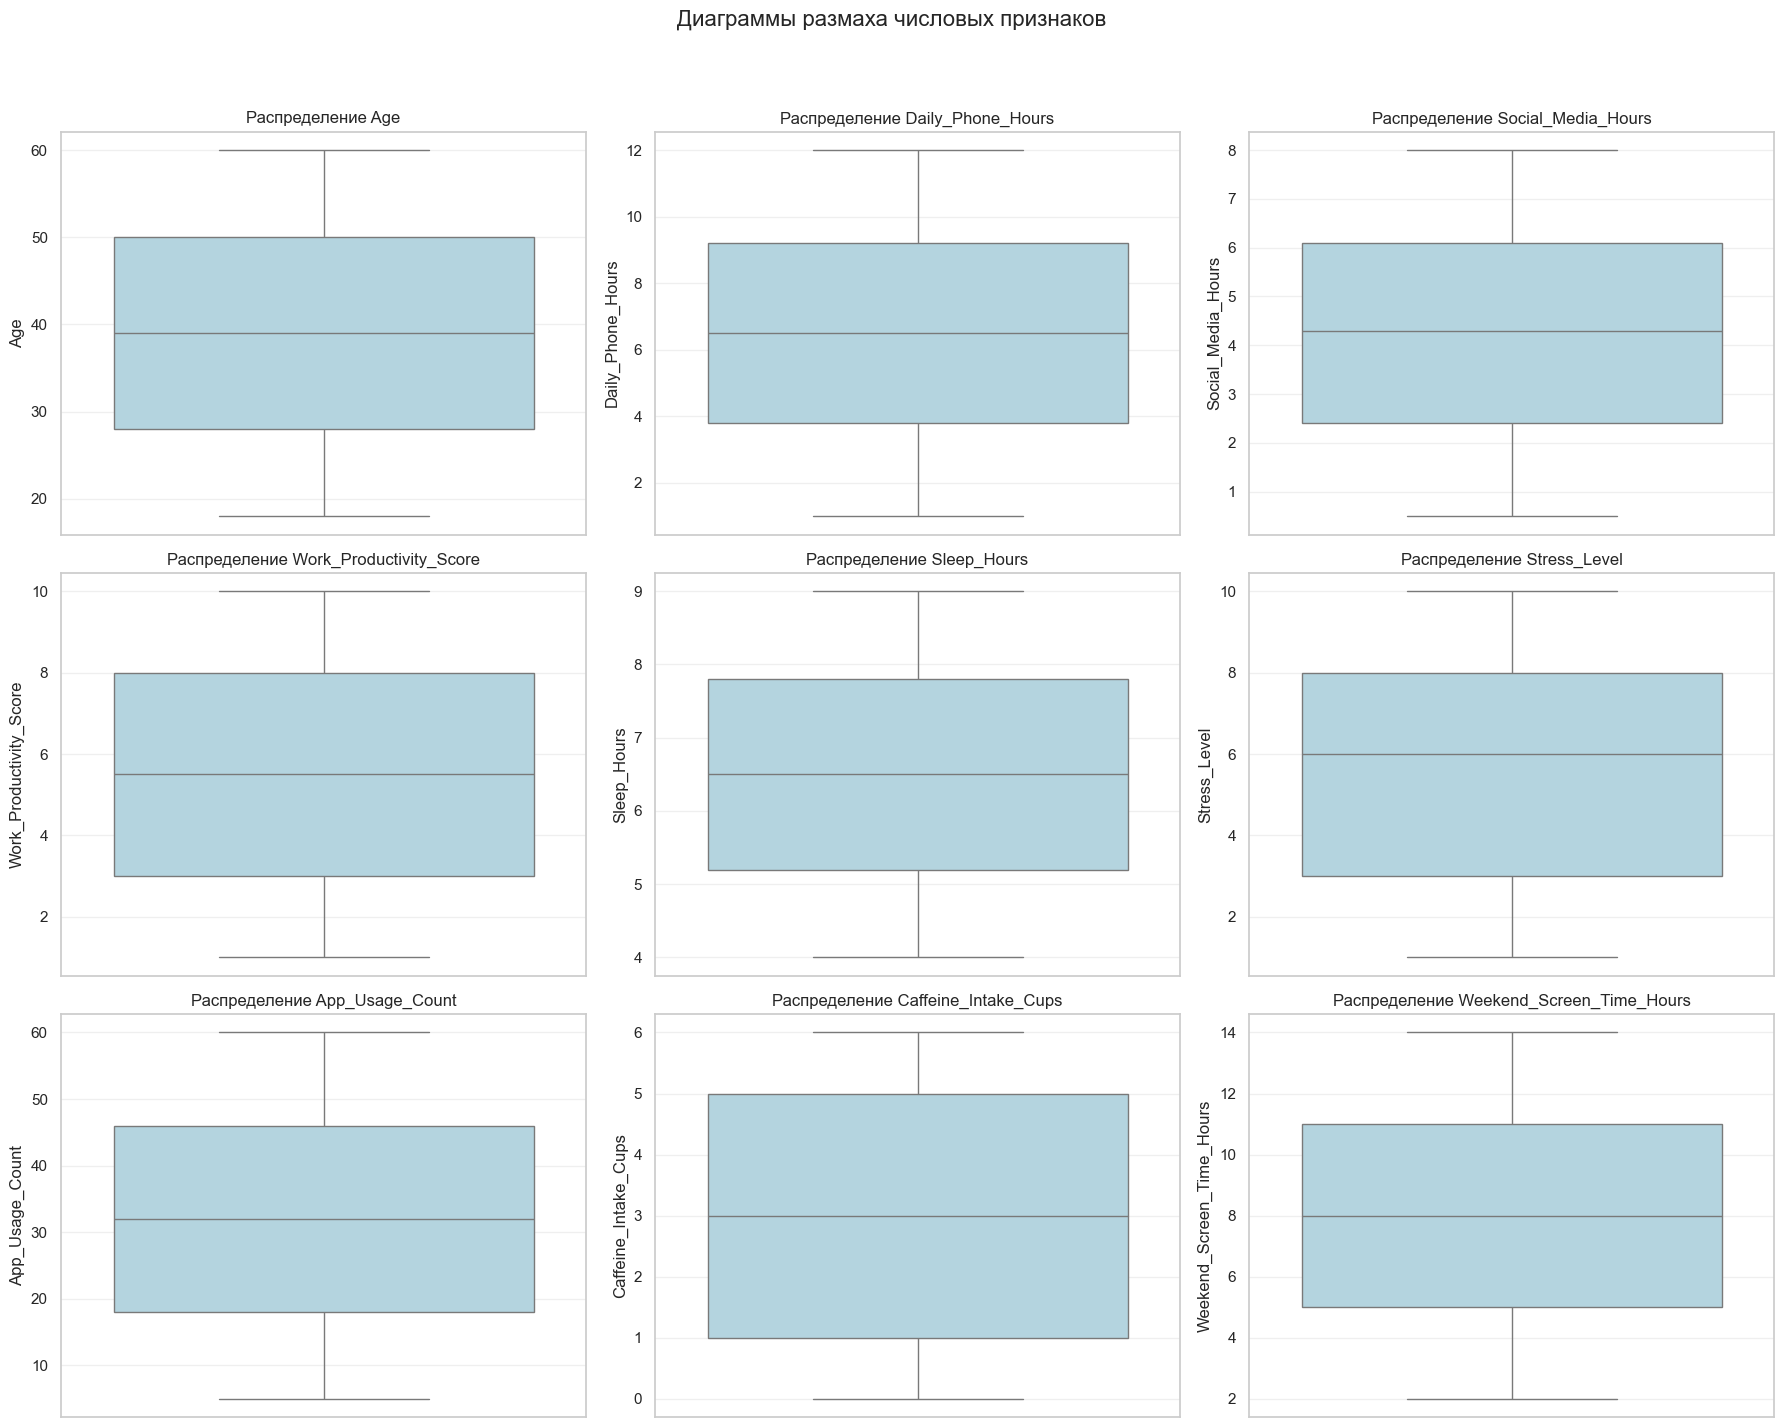

In [61]:
#box plots для всех числовых признаков
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Диаграммы размаха числовых признаков', fontsize=16)

numeric_features = ['Age', 'Daily_Phone_Hours', 'Social_Media_Hours', 
                    'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level',
                    'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours']

for i, feature in enumerate(numeric_features):
    row = i // 3
    col = i % 3
    
    #строим box plot
    sns.boxplot(data=data, y=feature, ax=axes[row, col], color='lightblue')
    axes[row, col].set_title(f'Распределение {feature}')
    axes[row, col].set_ylabel(feature)
    
    #добавим сетку 
    axes[row, col].grid(True, axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4) Информация о корреляции признаков

Проверка корреляции признаков позволяет решить две задачи:
1. Понять какие признаки (колонки датасета) наиболее сильно коррелируют с целевым признаком (в нашем примере это колонка "Occupancy"). Именно эти признаки будут наиболее информативными для моделей машинного обучения. Признаки, которые слабо коррелируют с целевым признаком, можно попробовать исключить из построения модели, иногда это повышает качество модели. Нужно отметить, что некоторые алгоритмы машинного обучения автоматически определяют ценность того или иного признака для построения модели.
2. Понять какие нецелевые признаки линейно зависимы между собой. Линейно зависимые признаки, как правило, очень плохо влияют на качество моделей. Поэтому если несколько признаков линейно зависимы, то для построения модели из них выбирают какой-то один признак.



Тепловая карта: Axes(0.125,0.11;0.62x0.77)


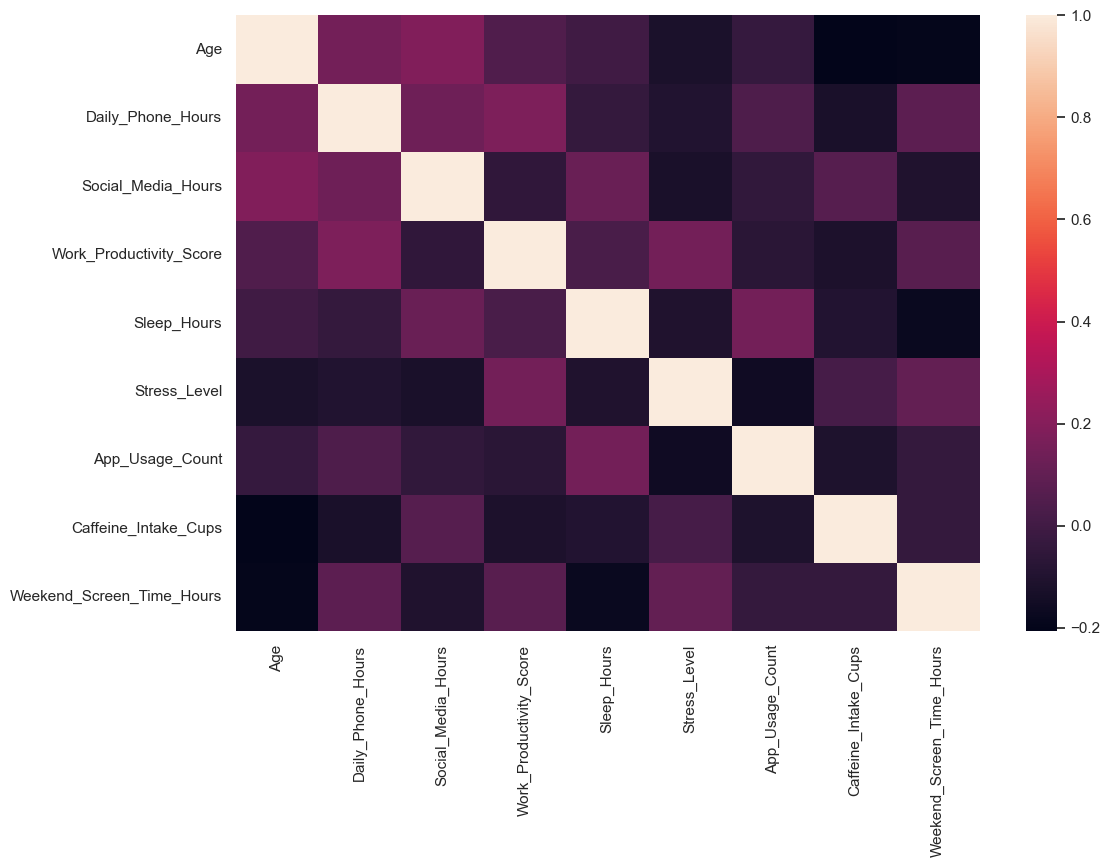

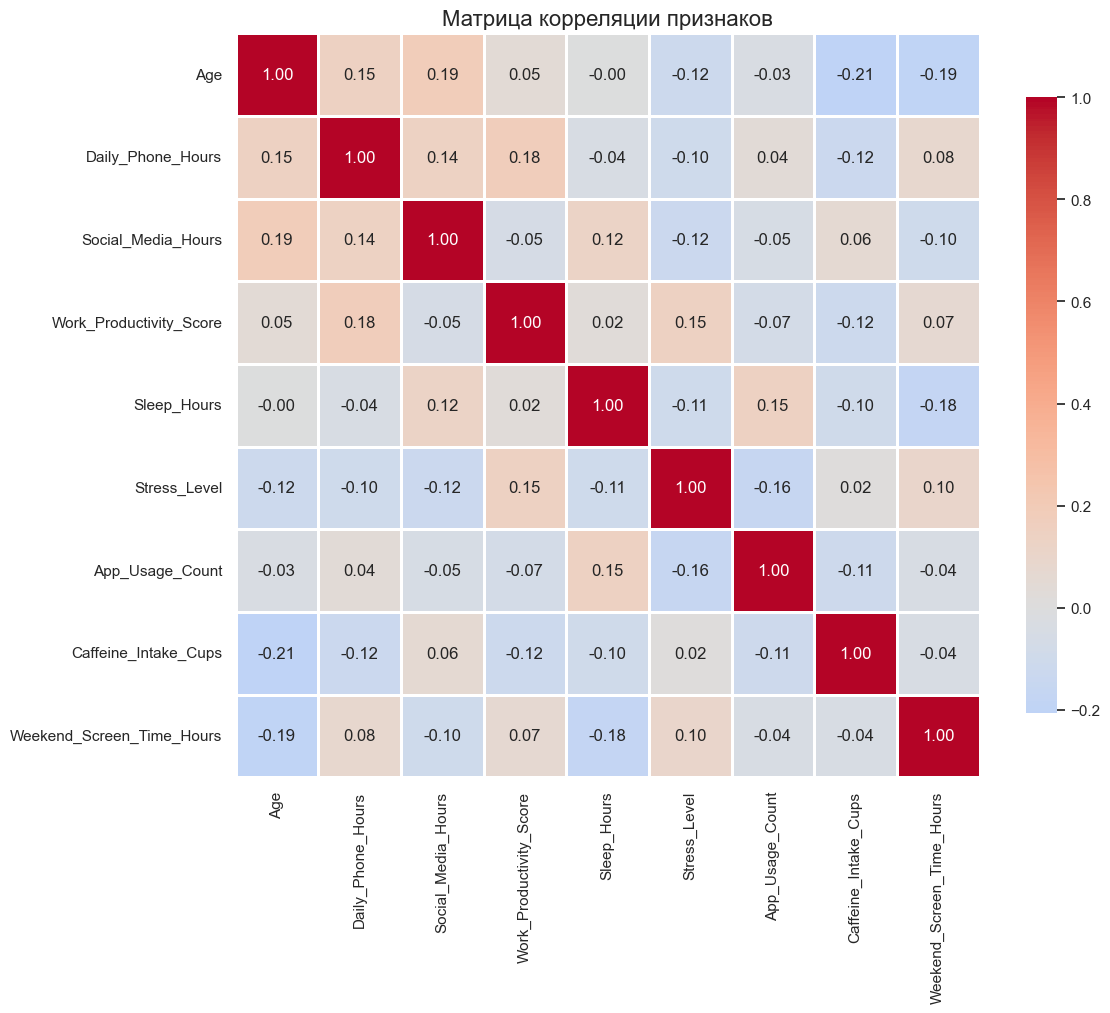

Значительные корреляции с продуктивностью:
Daily_Phone_Hours            0.175136
Stress_Level                 0.149061
Weekend_Screen_Time_Hours    0.067619
Age                          0.046931
Sleep_Hours                  0.024177
Name: Work_Productivity_Score, dtype: float64

Значительные корреляции со стрессом:
Work_Productivity_Score      0.149061
Weekend_Screen_Time_Hours    0.101031
Caffeine_Intake_Cups         0.015912
Daily_Phone_Hours           -0.102307
Sleep_Hours                 -0.106173
Name: Stress_Level, dtype: float64


In [123]:
#только числовые столбцы
data_sample = data.sample(n=100, random_state=42)
numeric_data = data_sample.select_dtypes(include=[np.number])

#удаляем User_ID 
#numeric_data = numeric_data.drop('User_ID', axis=1)

#print(numeric_data.corr(method='pearson'))

#считаем корреляционную матрицу
correlation_matrix = numeric_data.corr()

#строим тепловую карту
print("Тепловая карта:", sns.heatmap(numeric_data.corr()))
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляции признаков', fontsize=16)
plt.show()

#самые сильные корреляции
print("Значительные корреляции с продуктивностью:")
print(correlation_matrix['Work_Productivity_Score'].sort_values(ascending=False)[1:6])

print("\nЗначительные корреляции со стрессом:")
print(correlation_matrix['Stress_Level'].sort_values(ascending=False)[1:6])